## 19.5. Asynchronous Successive Halving (AHSH)

In [8]:
import logging
from d2l import torch as d2l

logging.basicConfig(level=logging.INFO)
import matplotlib.pyplot as plt
from syne_tune import StoppingCriterion, Tuner
from syne_tune.backend.python_backend import PythonBackend
from syne_tune.config_space import loguniform, randint
from syne_tune.experiments import load_experiment
from syne_tune.optimizer.baselines import ASHA

### 19.5.1. Objective Function

In [2]:
def hpo_objective_lenet_synetune(learning_rate, batch_size, max_epochs):
  from syne_tune import Reporter
  from d2l import torch as d2l
  
  model = d2l.LeNet(lr=learning_rate, num_classes=10)
  trainer = d2l.HPOTrainer(max_epochs=1, num_gpus=1)
  data = d2l.FashionMNIST(batch_size=batch_size)
  model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
  report = Reporter()
  for epoch in range(1, max_epochs + 1):
    if epoch == 1:
      # Init the state of the Trainer
      trainer.fit(model=model, data=data)
    else:
      trainer.fit_epoch()
    
    validation_error = trainer.validation_error().cpu().detach().numpy()
    report(epoch=epoch, validation_error=float(validation_error))

In [5]:
min_number_of_epochs = 2
max_number_of_epochs = 10
eta = 2

config_space = {
  "learning_rate": loguniform(1e-2, 1),
  "batch_size": randint(32, 256),
  "max_epochs": max_number_of_epochs,
}

initial_config = {
  "learning_rate": 0.1,
  "batch_size": 128,
}

### 19.5.2. Asynchronous Scheduler

In [6]:
n_workers = 2 # Needs to <= #GPUs
max_wallclock_time = 12 * 60 # 12 min

In [7]:
mode="min"
metric = "validation_error"
resource_attr = "epoch"

scheduler = ASHA(
  config_space,
  metric=metric,
  mode=mode,
  points_to_evaluate=[initial_config],
  max_resource_attr="max_epochs",
  resource_attr=resource_attr,
  grace_period=min_number_of_epochs,
  reduction_factor=eta,
)

In [10]:
trial_backend = PythonBackend(
  tune_function=hpo_objective_lenet_synetune,
  config_space=config_space,
)

stop_criterion = StoppingCriterion(max_wallclock_time=max_wallclock_time)
tuner=Tuner(
  trial_backend=trial_backend,
  scheduler=scheduler,
  stop_criterion=stop_criterion,
  n_workers=n_workers,
  print_update_interval=int(max_wallclock_time * 0.6)
)
tuner.run()

--------------------
Resource summary (last result is reported):
 trial_id     status  iter  learning_rate  batch_size  max_epochs  epoch  validation_error  worker-time
        0     Failed     8       0.100000         128          10    8.0          0.294403   333.742860
        1    Stopped    10       0.326894          42          10   10.0          0.140367   410.894812
        2    Stopped    10       0.495788          86          10   10.0          0.157656   276.743037
        3    Stopped     2       0.281696         120          10    2.0          0.404663    57.264089
        4    Stopped     2       0.048449         184          10    2.0          0.900074    51.471157
        5    Stopped     2       0.012449         105          10    2.0          0.900476    50.342046
        6    Stopped     2       0.030326         169          10    2.0          0.900428    57.618221
        7 InProgress     1       0.288248          89          10    1.0          0.900035    28.215058

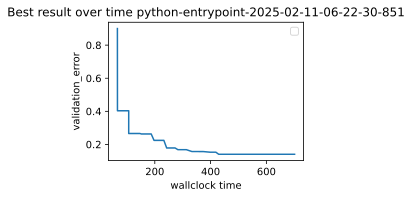

In [11]:
d2l.set_figsize()
e = load_experiment(tuner.name)
e.plot()

### 19.5.3. Visualize the Optimization Process

Text(0, 0.5, 'objective function')

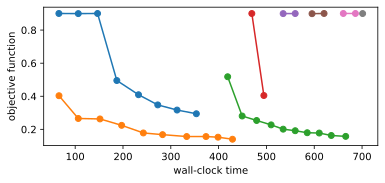

In [12]:
d2l.set_figsize([6, 2.5])
results = e.results
for trial_id in results.trial_id.unique():
  df = results[results["trial_id"] == trial_id]
  d2l.plt.plot(
    df["st_tuner_time"],
    df["validation_error"],
    marker="o"
  )
d2l.plt.xlabel("wall-clock time")
d2l.plt.ylabel("objective function")